# 3.3.5 Sensor Fusion: Cell State Estimation from Multi-Omics

This notebook illustrates **sensor fusion** from Chapter 3.3.5 using a real-world scenario: estimating the true state of a cell on a differentiation landscape by combining multiple omics assays with different noise characteristics.

## The Problem

A research team is characterizing a rare progenitor cell isolated from a bone marrow sample. They want to pinpoint its position on a 2D differentiation landscape defined by two axes:

1. **Differentiation score** ($z_1$): How far the cell has progressed from stem-like to mature
2. **Lineage score** ($z_2$): Which lineage the cell is committing to (e.g., myeloid vs. lymphoid)

They have three different assays, each providing a noisy estimate of the cell's state:

1. **RNA-seq**: Captures overall transcriptomic profile — moderate accuracy in both axes
2. **Flow cytometry**: Measures surface markers (CD34, CD38, etc.) — very precise for differentiation stage, but noisy for lineage
3. **ATAC-seq**: Measures chromatin accessibility at lineage-specific loci — precise for lineage commitment, but noisy for differentiation

Each assay provides a noisy estimate of the cell's 2D state $(z_1, z_2)$, but with different error characteristics. How do we optimally combine these measurements?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import linalg

np.random.seed(42)

plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['font.size'] = 12

## Mathematical Background: Sensor Fusion

From Section 3.3.5, when we have $M$ sensors (here, assays) each providing measurements of an unknown state $\mathbf{z}$, the model is:

$$p(\mathbf{z}, \mathbf{y}) = p(\mathbf{z}) \prod_{m=1}^{M} \prod_{n=1}^{N_m} \mathcal{N}(\mathbf{y}_{n,m} | \mathbf{z}, \boldsymbol{\Sigma}_m)$$

where:
- $\mathbf{z} \in \mathbb{R}^D$ is the true (unknown) cell state
- $\mathbf{y}_{n,m}$ is the $n$-th observation from assay $m$
- $\boldsymbol{\Sigma}_m$ is the noise covariance of assay $m$

### Bayes Rule for Gaussians

Using **Bayes rule for Gaussians** (Equation 3.37), the posterior is:

$$p(\mathbf{z}|\mathbf{y}) = \mathcal{N}(\mathbf{z}|\boldsymbol{\mu}_{z|y}, \boldsymbol{\Sigma}_{z|y})$$

where:
$$\boldsymbol{\Sigma}_{z|y}^{-1} = \boldsymbol{\Sigma}_z^{-1} + \sum_{m=1}^{M} N_m \boldsymbol{\Sigma}_m^{-1}$$

$$\boldsymbol{\mu}_{z|y} = \boldsymbol{\Sigma}_{z|y} \left[ \boldsymbol{\Sigma}_z^{-1} \boldsymbol{\mu}_z + \sum_{m=1}^{M} \boldsymbol{\Sigma}_m^{-1} (N_m \bar{\mathbf{y}}_m) \right]$$

**Key insight**: The posterior precision (inverse covariance) is the sum of individual precisions. More reliable assays (lower variance = higher precision) contribute more to the final estimate.

## Setting Up the Scenario

Let's define our three assays with realistic noise characteristics:

- **RNA-seq**: Isotropic noise (captures both axes roughly equally), moderate accuracy
- **Flow cytometry**: Very accurate for differentiation ($z_1$), less accurate for lineage ($z_2$) — surface markers like CD34/CD38 track differentiation stages well, but are less informative about lineage
- **ATAC-seq**: Accurate for lineage ($z_2$) from lineage-specific enhancer accessibility, but noisy for differentiation ($z_1$)

In [2]:
# True cell state (unknown to the assays)
z_true = np.array([10.0, 5.0])  # True position on differentiation landscape

# Assay noise covariance matrices
# RNA-seq: isotropic noise, moderate in both axes
Sigma_rnaseq = np.array([[4.0, 0.0],
                         [0.0, 4.0]])

# Flow cytometry: very accurate for differentiation (z1), less for lineage (z2)
# Some correlation from shared marker signals
Sigma_flow = np.array([[0.25, 0.1],
                       [0.1,  1.0]])

# ATAC-seq: poor differentiation (z1), good lineage (z2)
Sigma_atac = np.array([[2.5, -0.2],
                       [-0.2, 0.16]])

# Prior: reference from Human Cell Atlas (rough population-level expectation)
mu_prior = np.array([9.0, 6.0])  # Prior mean
Sigma_prior = np.array([[9.0, 0.0],   # Prior covariance (fairly uncertain)
                        [0.0, 9.0]])

print("Assay Noise Standard Deviations:")
print(f"RNA-seq:        sigma_diff = {np.sqrt(Sigma_rnaseq[0,0]):.2f}, sigma_lin = {np.sqrt(Sigma_rnaseq[1,1]):.2f}")
print(f"Flow cytometry: sigma_diff = {np.sqrt(Sigma_flow[0,0]):.2f}, sigma_lin = {np.sqrt(Sigma_flow[1,1]):.2f}")
print(f"ATAC-seq:       sigma_diff = {np.sqrt(Sigma_atac[0,0]):.2f}, sigma_lin = {np.sqrt(Sigma_atac[1,1]):.2f}")

Assay Noise Standard Deviations:
RNA-seq:        sigma_diff = 2.00, sigma_lin = 2.00
Flow cytometry: sigma_diff = 0.50, sigma_lin = 1.00
ATAC-seq:       sigma_diff = 1.58, sigma_lin = 0.40


## Generating Assay Measurements

Each assay is run with multiple replicates. We simulate realistic scenarios where some assays may have more replicates than others (e.g., flow cytometry is cheap and fast, ATAC-seq is more commonly run).

In [3]:
def generate_measurements(z_true, Sigma, n_measurements):
    """Generate n noisy measurements from an assay with covariance Sigma."""
    return np.random.multivariate_normal(z_true, Sigma, n_measurements)

# Number of replicates from each assay
n_rnaseq = 5    # RNA-seq: expensive, fewer replicates
n_flow = 10     # Flow cytometry: fast and cheap, more replicates
n_atac = 15     # ATAC-seq: commonly pooled across conditions

# Generate measurements
y_rnaseq = generate_measurements(z_true, Sigma_rnaseq, n_rnaseq)
y_flow = generate_measurements(z_true, Sigma_flow, n_flow)
y_atac = generate_measurements(z_true, Sigma_atac, n_atac)

# Compute sample means
y_bar_rnaseq = y_rnaseq.mean(axis=0)
y_bar_flow = y_flow.mean(axis=0)
y_bar_atac = y_atac.mean(axis=0)

print("Sample means (estimates from each assay):")
print(f"True cell state:       ({z_true[0]:.2f}, {z_true[1]:.2f})")
print(f"RNA-seq mean (n={n_rnaseq}):    ({y_bar_rnaseq[0]:.2f}, {y_bar_rnaseq[1]:.2f})")
print(f"Flow cyt. mean (n={n_flow}):  ({y_bar_flow[0]:.2f}, {y_bar_flow[1]:.2f})")
print(f"ATAC-seq mean (n={n_atac}):  ({y_bar_atac[0]:.2f}, {y_bar_atac[1]:.2f})")

Sample means (estimates from each assay):
True cell state:       (10.00, 5.00)
RNA-seq mean (n=5):    (10.81, 5.98)
Flow cyt. mean (n=10):  (9.67, 4.57)
ATAC-seq mean (n=15):  (10.18, 4.94)


## Visualizing Individual Assay Measurements

Let's visualize the measurements from each assay along with their uncertainty ellipses.

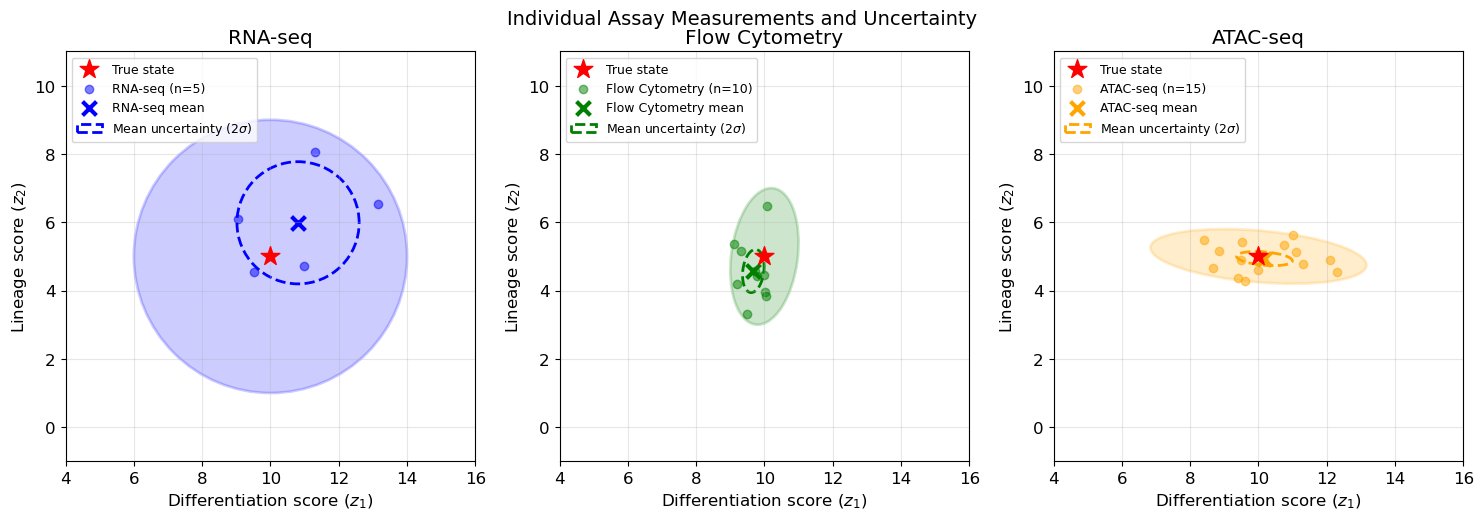

In [4]:
def plot_covariance_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """
    Plot an ellipse representing the covariance matrix.
    n_std: number of standard deviations for the ellipse radius
    """
    eigenvalues, eigenvectors = linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width = 2 * n_std * np.sqrt(eigenvalues[0])
    height = 2 * n_std * np.sqrt(eigenvalues[1])
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

assays = [
    ('RNA-seq', y_rnaseq, y_bar_rnaseq, Sigma_rnaseq, 'blue', n_rnaseq),
    ('Flow Cytometry', y_flow, y_bar_flow, Sigma_flow, 'green', n_flow),
    ('ATAC-seq', y_atac, y_bar_atac, Sigma_atac, 'orange', n_atac)
]

for ax, (name, measurements, mean, cov, color, n) in zip(axes, assays):
    ax.scatter(*z_true, s=200, c='red', marker='*', zorder=5, label='True state')
    ax.scatter(measurements[:, 0], measurements[:, 1], c=color, alpha=0.5,
               label=f'{name} (n={n})')
    ax.scatter(*mean, s=100, c=color, marker='x', linewidths=3,
               label=f'{name} mean')
    plot_covariance_ellipse(ax, z_true, cov, n_std=2.0,
                           facecolor=color, alpha=0.2, edgecolor=color, linewidth=2)
    plot_covariance_ellipse(ax, mean, cov/n, n_std=2.0,
                           facecolor='none', edgecolor=color, linewidth=2, linestyle='--',
                           label=f'Mean uncertainty (2$\\sigma$)')
    ax.set_xlabel('Differentiation score ($z_1$)')
    ax.set_ylabel('Lineage score ($z_2$)')
    ax.set_title(f'{name}')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(4, 16)
    ax.set_ylim(-1, 11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Individual Assay Measurements and Uncertainty', y=1.02, fontsize=14)
plt.show()

Notice how each assay has different uncertainty characteristics:
- **RNA-seq**: Circular uncertainty (isotropic) — captures both axes with similar noise
- **Flow cytometry**: Elongated vertically — surface markers like CD34/CD38 precisely track differentiation stage, but are less informative about lineage commitment
- **ATAC-seq**: Elongated horizontally — lineage-specific enhancer accessibility gives sharp lineage readout, but differentiation timing is noisy

## Implementing Multi-Omics Fusion

Now we implement the sensor fusion using Bayes rule for Gaussians.

In [5]:
def sensor_fusion(mu_prior, Sigma_prior, measurements_list, covariances_list):
    """
    Perform Bayesian sensor fusion for multiple assays.

    Parameters
    ----------
    mu_prior : array, shape (D,)
        Prior mean
    Sigma_prior : array, shape (D, D)
        Prior covariance
    measurements_list : list of arrays, each shape (N_m, D)
        Measurements from each assay
    covariances_list : list of arrays, each shape (D, D)
        Noise covariance for each assay

    Returns
    -------
    mu_posterior : array, shape (D,)
        Posterior mean (fused estimate)
    Sigma_posterior : array, shape (D, D)
        Posterior covariance (fused uncertainty)
    """
    Lambda_posterior = linalg.inv(Sigma_prior)
    eta_posterior = Lambda_posterior @ mu_prior

    for measurements, Sigma_m in zip(measurements_list, covariances_list):
        n_m = len(measurements)
        y_bar_m = measurements.mean(axis=0)
        Lambda_m = linalg.inv(Sigma_m)
        Lambda_posterior += n_m * Lambda_m
        eta_posterior += Lambda_m @ (n_m * y_bar_m)

    Sigma_posterior = linalg.inv(Lambda_posterior)
    mu_posterior = Sigma_posterior @ eta_posterior

    return mu_posterior, Sigma_posterior

# Perform multi-omics fusion
measurements_list = [y_rnaseq, y_flow, y_atac]
covariances_list = [Sigma_rnaseq, Sigma_flow, Sigma_atac]

mu_fused, Sigma_fused = sensor_fusion(mu_prior, Sigma_prior,
                                       measurements_list, covariances_list)

print("\n=== MULTI-OMICS FUSION RESULTS ===")
print(f"\nTrue cell state:  ({z_true[0]:.3f}, {z_true[1]:.3f})")
print(f"\nPrior (atlas):    ({mu_prior[0]:.3f}, {mu_prior[1]:.3f})")
print(f"Prior std:        ({np.sqrt(Sigma_prior[0,0]):.3f}, {np.sqrt(Sigma_prior[1,1]):.3f})")
print(f"\nFused estimate:   ({mu_fused[0]:.3f}, {mu_fused[1]:.3f})")
print(f"Fused std:        ({np.sqrt(Sigma_fused[0,0]):.3f}, {np.sqrt(Sigma_fused[1,1]):.3f})")

prior_error = linalg.norm(mu_prior - z_true)
fused_error = linalg.norm(mu_fused - z_true)
print(f"\nPrior error:      {prior_error:.3f}")
print(f"Fused error:      {fused_error:.3f}")
print(f"Error reduction:  {100*(prior_error - fused_error)/prior_error:.1f}%")


=== MULTI-OMICS FUSION RESULTS ===

True cell state:  (10.000, 5.000)

Prior (atlas):    (9.000, 6.000)
Prior std:        (3.000, 3.000)

Fused estimate:   (9.798, 4.948)
Fused std:        (0.142, 0.093)

Prior error:      1.414
Fused error:      0.208
Error reduction:  85.3%


## Visualizing the Fused Estimate

Let's compare the individual assay estimates with the fused result.

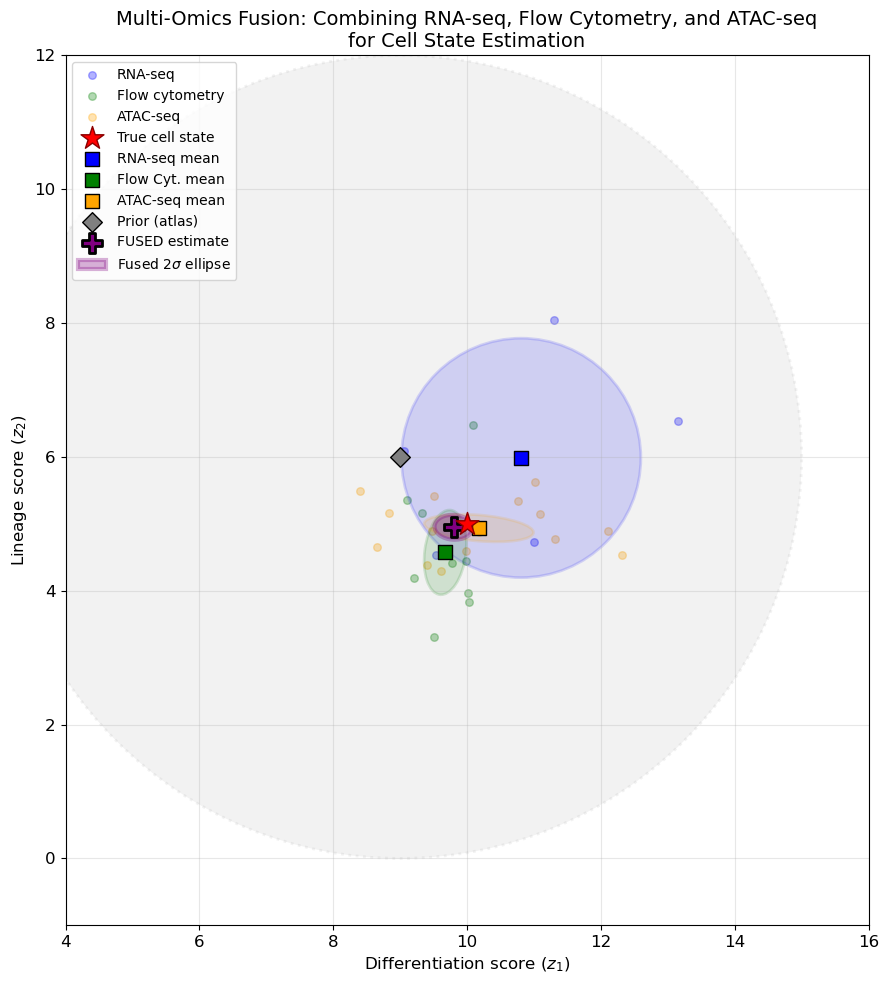

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot all measurements (faded)
ax.scatter(y_rnaseq[:, 0], y_rnaseq[:, 1], c='blue', alpha=0.3, s=30, label='RNA-seq')
ax.scatter(y_flow[:, 0], y_flow[:, 1], c='green', alpha=0.3, s=30, label='Flow cytometry')
ax.scatter(y_atac[:, 0], y_atac[:, 1], c='orange', alpha=0.3, s=30, label='ATAC-seq')

# Plot true state
ax.scatter(*z_true, s=300, c='red', marker='*', zorder=10, label='True cell state', edgecolors='darkred')

# Plot individual assay means with their uncertainty ellipses
colors = ['blue', 'green', 'orange']
names = ['RNA-seq', 'Flow Cyt.', 'ATAC-seq']
means = [y_bar_rnaseq, y_bar_flow, y_bar_atac]
covs = [Sigma_rnaseq/n_rnaseq, Sigma_flow/n_flow, Sigma_atac/n_atac]

for name, mean, cov, color in zip(names, means, covs, colors):
    ax.scatter(*mean, s=100, c=color, marker='s', edgecolors='black', linewidth=1,
               label=f'{name} mean', zorder=6)
    plot_covariance_ellipse(ax, mean, cov, n_std=2.0,
                           facecolor=color, alpha=0.15, edgecolor=color, linewidth=2)

# Plot prior
ax.scatter(*mu_prior, s=100, c='gray', marker='D', edgecolors='black', linewidth=1,
           label='Prior (atlas)', zorder=6)
plot_covariance_ellipse(ax, mu_prior, Sigma_prior, n_std=2.0,
                       facecolor='gray', alpha=0.1, edgecolor='gray', linewidth=2, linestyle=':')

# Plot fused estimate
ax.scatter(*mu_fused, s=200, c='purple', marker='P', edgecolors='black', linewidth=2,
           label='FUSED estimate', zorder=8)
plot_covariance_ellipse(ax, mu_fused, Sigma_fused, n_std=2.0,
                       facecolor='purple', alpha=0.3, edgecolor='purple', linewidth=3,
                       label='Fused 2$\\sigma$ ellipse')

ax.set_xlabel('Differentiation score ($z_1$)', fontsize=12)
ax.set_ylabel('Lineage score ($z_2$)', fontsize=12)
ax.set_title('Multi-Omics Fusion: Combining RNA-seq, Flow Cytometry, and ATAC-seq\nfor Cell State Estimation', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(4, 16)
ax.set_ylim(-1, 12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Understanding the Fusion: Precision Weighting

The key insight is that multi-omics fusion works by **adding precisions** (inverse covariances). Let's visualize how each assay contributes to the final estimate.

In [7]:
# Compute precision matrices
Lambda_prior = linalg.inv(Sigma_prior)
Lambda_rnaseq = n_rnaseq * linalg.inv(Sigma_rnaseq)
Lambda_flow = n_flow * linalg.inv(Sigma_flow)
Lambda_atac = n_atac * linalg.inv(Sigma_atac)
Lambda_total = Lambda_prior + Lambda_rnaseq + Lambda_flow + Lambda_atac

def precision_contribution(Lambda_sensor, Lambda_total):
    """Compute the relative contribution of an assay to total precision."""
    return np.trace(Lambda_sensor) / np.trace(Lambda_total) * 100

print("=== PRECISION ANALYSIS ===")
print("\nPrecision matrices (inverse covariance, weighted by n_replicates):")
print(f"\nPrior precision trace:            {np.trace(Lambda_prior):.2f}")
print(f"RNA-seq precision trace (n={n_rnaseq}):    {np.trace(Lambda_rnaseq):.2f}")
print(f"Flow cyt. precision trace (n={n_flow}):  {np.trace(Lambda_flow):.2f}")
print(f"ATAC-seq precision trace (n={n_atac}):  {np.trace(Lambda_atac):.2f}")
print(f"Total precision trace:            {np.trace(Lambda_total):.2f}")

print("\n--- Relative Contributions ---")
contributions = {
    'Prior': precision_contribution(Lambda_prior, Lambda_total),
    'RNA-seq': precision_contribution(Lambda_rnaseq, Lambda_total),
    'Flow Cyt.': precision_contribution(Lambda_flow, Lambda_total),
    'ATAC-seq': precision_contribution(Lambda_atac, Lambda_total)
}

for name, contrib in contributions.items():
    print(f"{name}: {contrib:.1f}%")

=== PRECISION ANALYSIS ===

Precision matrices (inverse covariance, weighted by n_replicates):

Prior precision trace:            0.22
RNA-seq precision trace (n=5):    2.50
Flow cyt. precision trace (n=10):  52.08
ATAC-seq precision trace (n=15):  110.83
Total precision trace:            165.64

--- Relative Contributions ---
Prior: 0.1%
RNA-seq: 1.5%
Flow Cyt.: 31.4%
ATAC-seq: 66.9%


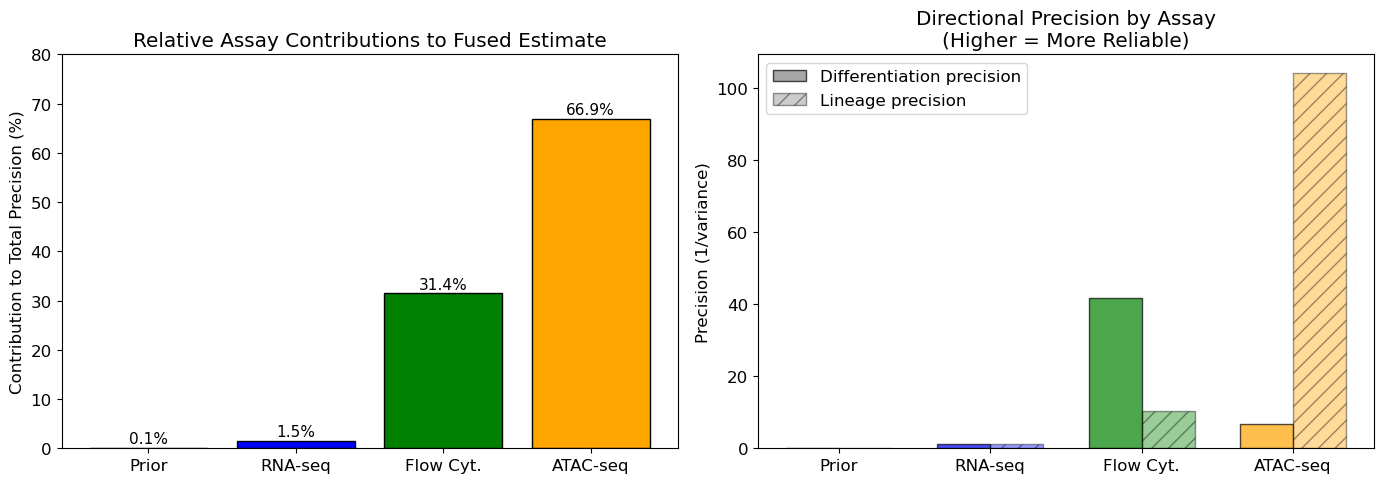

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of contributions
ax = axes[0]
colors = ['gray', 'blue', 'green', 'orange']
bars = ax.bar(contributions.keys(), contributions.values(), color=colors, edgecolor='black')
ax.set_ylabel('Contribution to Total Precision (%)')
ax.set_title('Relative Assay Contributions to Fused Estimate')
ax.set_ylim(0, 80)
for bar, val in zip(bars, contributions.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11)

# Right: Directional precision (differentiation vs lineage)
ax = axes[1]

assays_data = [
    ('Prior', Lambda_prior, 'gray'),
    ('RNA-seq', Lambda_rnaseq, 'blue'),
    ('Flow Cyt.', Lambda_flow, 'green'),
    ('ATAC-seq', Lambda_atac, 'orange'),
]

x_positions = np.arange(len(assays_data))
width = 0.35

diff_precisions = [s[1][0,0] for s in assays_data]
lin_precisions = [s[1][1,1] for s in assays_data]
a_names = [s[0] for s in assays_data]
a_colors = [s[2] for s in assays_data]

bars1 = ax.bar(x_positions - width/2, diff_precisions, width, label='Differentiation precision',
               color=a_colors, alpha=0.7, edgecolor='black')
bars2 = ax.bar(x_positions + width/2, lin_precisions, width, label='Lineage precision',
               color=a_colors, alpha=0.4, edgecolor='black', hatch='//')

ax.set_xticks(x_positions)
ax.set_xticklabels(a_names)
ax.set_ylabel('Precision (1/variance)')
ax.set_title('Directional Precision by Assay\n(Higher = More Reliable)')
ax.legend()

plt.tight_layout()
plt.show()

## Anisotropic Fusion: The Power of Complementary Assays

Notice how the **fused uncertainty ellipse is much smaller than any individual assay's ellipse**. This is because:

1. **Flow cytometry** provides high precision in the differentiation direction ($z_1$)
2. **ATAC-seq** provides high precision in the lineage direction ($z_2$)
3. When combined, we get high precision in BOTH directions!

This is the power of **multi-omics integration**: assays with complementary strengths combine to produce a cell state estimate better than any single assay could achieve.

In [9]:
print("=== UNCERTAINTY COMPARISON ===")
print("\nStandard deviations:")
print(f"{'Assay':<20} {'sigma_diff':>12} {'sigma_lin':>12} {'Area*':>12}")
print("-" * 60)

def ellipse_area(Sigma):
    """Area of 1-sigma ellipse: pi * sqrt(det(Sigma))"""
    return np.pi * np.sqrt(linalg.det(Sigma))

comparisons = [
    ('Prior (atlas)', Sigma_prior),
    ('RNA-seq (mean)', Sigma_rnaseq/n_rnaseq),
    ('Flow cyt. (mean)', Sigma_flow/n_flow),
    ('ATAC-seq (mean)', Sigma_atac/n_atac),
    ('FUSED', Sigma_fused)
]

for name, Sigma in comparisons:
    sx = np.sqrt(Sigma[0,0])
    sy = np.sqrt(Sigma[1,1])
    area = ellipse_area(Sigma)
    print(f"{name:<20} {sx:>12.3f} {sy:>12.3f} {area:>12.4f}")

print("\n* Area of 1-sigma uncertainty ellipse")
print(f"\nUncertainty reduction (fused vs best single assay):")
best_single = min(ellipse_area(Sigma_rnaseq/n_rnaseq),
                  ellipse_area(Sigma_flow/n_flow),
                  ellipse_area(Sigma_atac/n_atac))
fused_area = ellipse_area(Sigma_fused)
print(f"Best single assay area: {best_single:.4f}")
print(f"Fused area:             {fused_area:.4f}")
print(f"Improvement:            {100*(best_single - fused_area)/best_single:.1f}%")

=== UNCERTAINTY COMPARISON ===

Standard deviations:
Assay                  sigma_diff    sigma_lin        Area*
------------------------------------------------------------
Prior (atlas)               3.000        3.000      28.2743
RNA-seq (mean)              0.894        0.894       2.5133
Flow cyt. (mean)            0.158        0.316       0.1539
ATAC-seq (mean)             0.408        0.103       0.1257
FUSED                       0.142        0.093       0.0415

* Area of 1-sigma uncertainty ellipse

Uncertainty reduction (fused vs best single assay):
Best single assay area: 0.1257
Fused area:             0.0415
Improvement:            67.0%


## Sequential Assay Integration

In practice, assay results arrive sequentially (RNA-seq might come back first, then flow, then ATAC-seq). Let's visualize how the estimate improves as we integrate each assay.

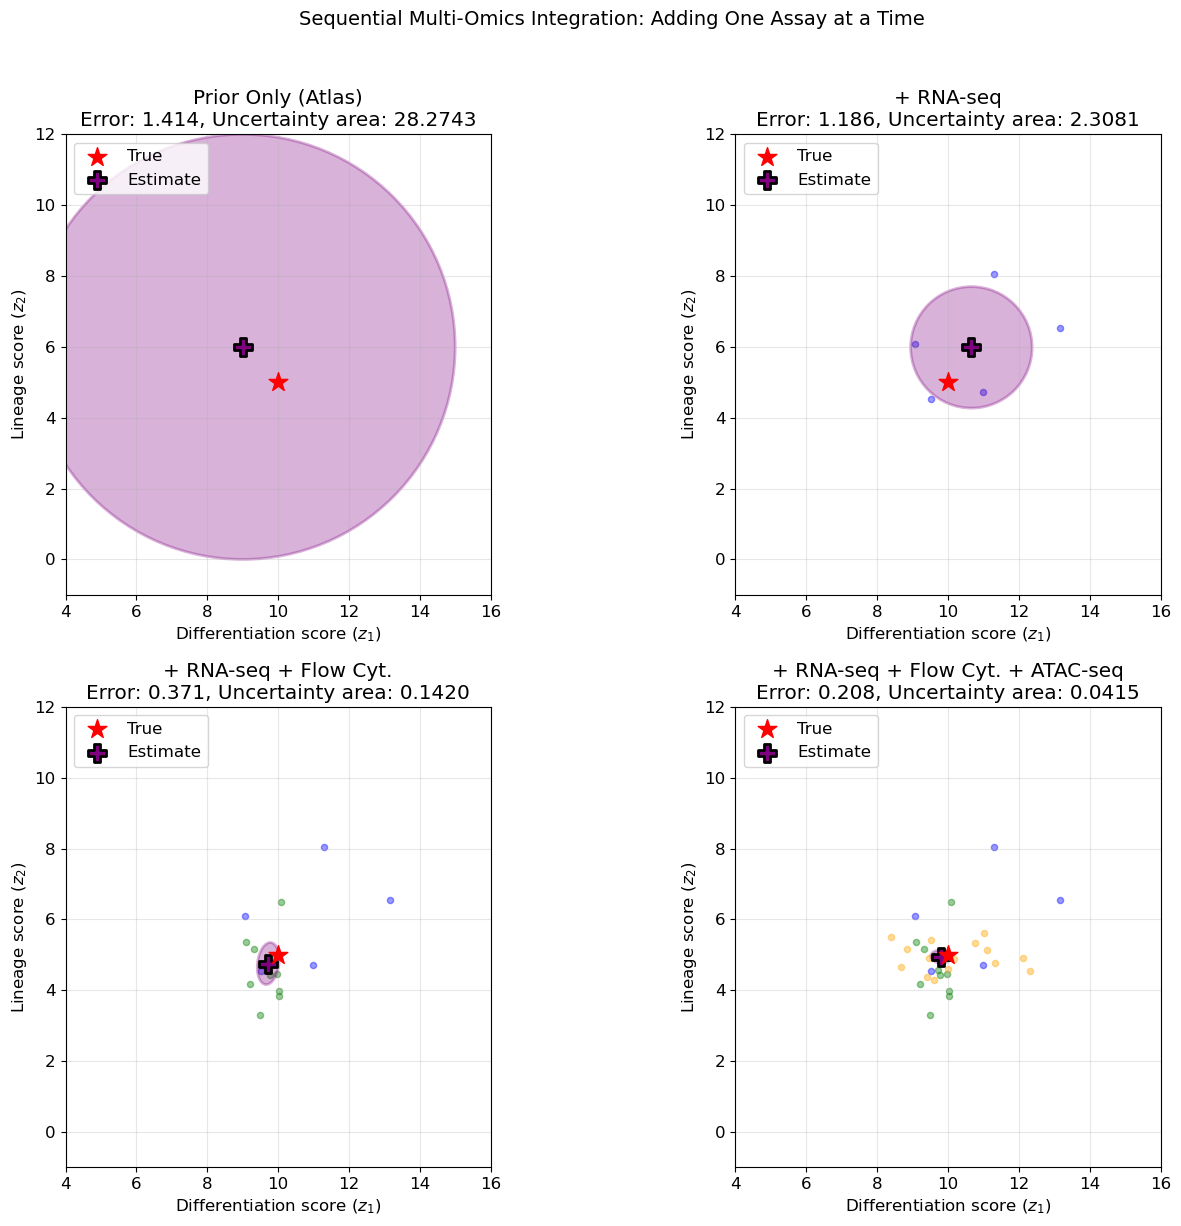

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Stage 0: Prior only
stages = [
    ('Prior Only (Atlas)', mu_prior, Sigma_prior, []),
]

# Stage 1: Prior + RNA-seq
mu1, Sigma1 = sensor_fusion(mu_prior, Sigma_prior, [y_rnaseq], [Sigma_rnaseq])
stages.append(('+ RNA-seq', mu1, Sigma1, [('RNA-seq', y_rnaseq, 'blue')]))

# Stage 2: Prior + RNA-seq + Flow
mu2, Sigma2 = sensor_fusion(mu_prior, Sigma_prior, [y_rnaseq, y_flow], [Sigma_rnaseq, Sigma_flow])
stages.append(('+ RNA-seq + Flow Cyt.', mu2, Sigma2,
               [('RNA-seq', y_rnaseq, 'blue'), ('Flow', y_flow, 'green')]))

# Stage 3: All assays
stages.append(('+ RNA-seq + Flow Cyt. + ATAC-seq', mu_fused, Sigma_fused,
               [('RNA-seq', y_rnaseq, 'blue'), ('Flow', y_flow, 'green'), ('ATAC', y_atac, 'orange')]))

for ax, (title, mu, Sigma, assay_data) in zip(axes, stages):
    ax.scatter(*z_true, s=200, c='red', marker='*', zorder=10, label='True')

    for name, measurements, color in assay_data:
        ax.scatter(measurements[:, 0], measurements[:, 1], c=color, alpha=0.4, s=20)

    ax.scatter(*mu, s=150, c='purple', marker='P', edgecolors='black', linewidth=2,
               label='Estimate', zorder=8)
    plot_covariance_ellipse(ax, mu, Sigma, n_std=2.0,
                           facecolor='purple', alpha=0.3, edgecolor='purple', linewidth=2)

    error = linalg.norm(mu - z_true)
    area = ellipse_area(Sigma)

    ax.set_xlabel('Differentiation score ($z_1$)')
    ax.set_ylabel('Lineage score ($z_2$)')
    ax.set_title(f'{title}\nError: {error:.3f}, Uncertainty area: {area:.4f}')
    ax.set_xlim(4, 16)
    ax.set_ylim(-1, 12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

plt.suptitle('Sequential Multi-Omics Integration: Adding One Assay at a Time', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Effect of Assay Quality

What happens if one assay produces low-quality data (e.g., RNA-seq with low sequencing depth)? The fusion framework naturally handles this by down-weighting unreliable assays.

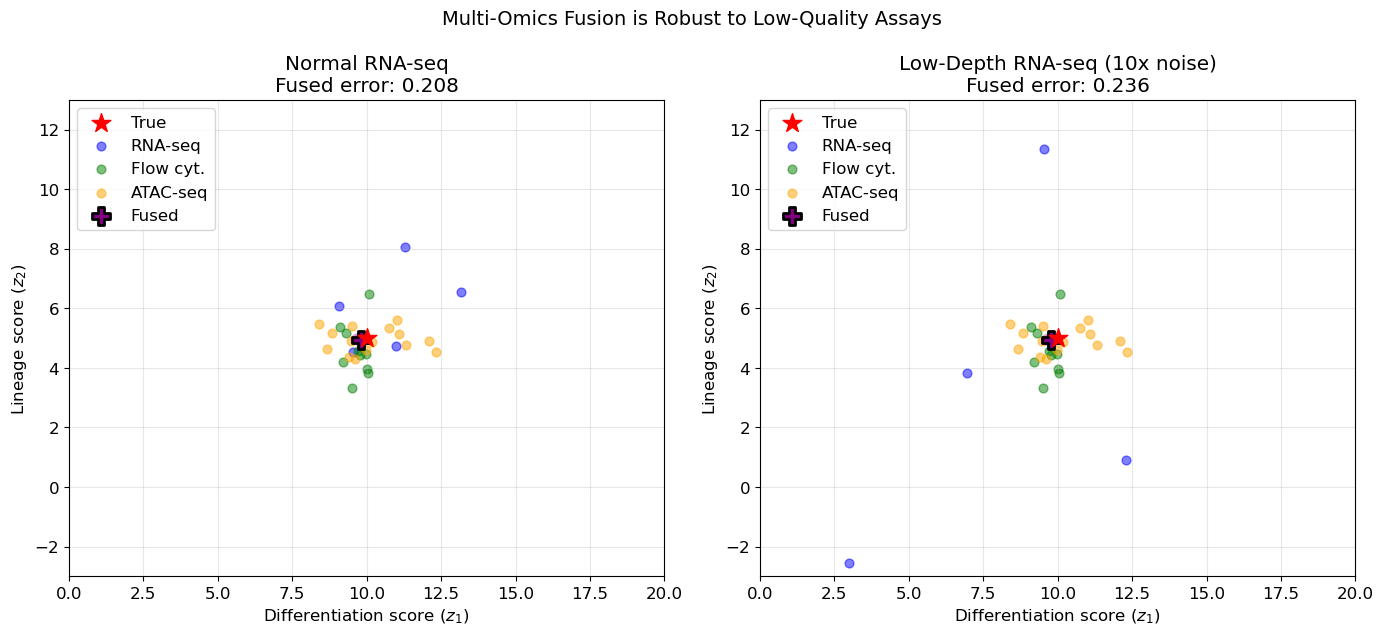


With low-depth RNA-seq, the fusion still works well because:
1. The degraded RNA-seq has lower precision, so it contributes less
2. Flow cytometry and ATAC-seq still provide reliable information

RNA-seq contribution (normal):   1.5%
RNA-seq contribution (degraded): 0.2%


In [11]:
# Simulate degraded RNA-seq (low sequencing depth → 10x more noise)
Sigma_rnaseq_degraded = Sigma_rnaseq * 10

# Regenerate RNA-seq measurements with degraded quality
y_rnaseq_degraded = generate_measurements(z_true, Sigma_rnaseq_degraded, n_rnaseq)

# Fusion with degraded RNA-seq
mu_degraded, Sigma_degraded = sensor_fusion(
    mu_prior, Sigma_prior,
    [y_rnaseq_degraded, y_flow, y_atac],
    [Sigma_rnaseq_degraded, Sigma_flow, Sigma_atac]
)

# Fusion with normal RNA-seq
mu_normal, Sigma_normal = sensor_fusion(
    mu_prior, Sigma_prior,
    [y_rnaseq, y_flow, y_atac],
    [Sigma_rnaseq, Sigma_flow, Sigma_atac]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (title, rna_data, rna_cov, mu_est, Sigma_est) in zip(axes, [
    ('Normal RNA-seq', y_rnaseq, Sigma_rnaseq, mu_normal, Sigma_normal),
    ('Low-Depth RNA-seq (10x noise)', y_rnaseq_degraded, Sigma_rnaseq_degraded, mu_degraded, Sigma_degraded)
]):
    ax.scatter(*z_true, s=200, c='red', marker='*', zorder=10, label='True')
    ax.scatter(rna_data[:, 0], rna_data[:, 1], c='blue', alpha=0.5, s=40, label='RNA-seq')
    ax.scatter(y_flow[:, 0], y_flow[:, 1], c='green', alpha=0.5, s=40, label='Flow cyt.')
    ax.scatter(y_atac[:, 0], y_atac[:, 1], c='orange', alpha=0.5, s=40, label='ATAC-seq')

    ax.scatter(*mu_est, s=150, c='purple', marker='P', edgecolors='black', linewidth=2,
               label='Fused', zorder=8)
    plot_covariance_ellipse(ax, mu_est, Sigma_est, n_std=2.0,
                           facecolor='purple', alpha=0.3, edgecolor='purple', linewidth=2)

    error = linalg.norm(mu_est - z_true)
    ax.set_xlabel('Differentiation score ($z_1$)')
    ax.set_ylabel('Lineage score ($z_2$)')
    ax.set_title(f'{title}\nFused error: {error:.3f}')
    ax.set_xlim(0, 20)
    ax.set_ylim(-3, 13)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

plt.suptitle('Multi-Omics Fusion is Robust to Low-Quality Assays', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nWith low-depth RNA-seq, the fusion still works well because:")
print("1. The degraded RNA-seq has lower precision, so it contributes less")
print("2. Flow cytometry and ATAC-seq still provide reliable information")
print(f"\nRNA-seq contribution (normal):   {precision_contribution(Lambda_rnaseq, Lambda_total):.1f}%")
print(f"RNA-seq contribution (degraded): {precision_contribution(n_rnaseq * linalg.inv(Sigma_rnaseq_degraded), Lambda_total):.1f}%")

## Key Takeaways

### From Chapter 3.3.5: Sensor Fusion

1. **Precision Addition**: When fusing Gaussian measurements, we add **precisions** (inverse covariances), not covariances. More reliable assays naturally contribute more.

2. **Complementary Assays**: Assays with different error characteristics can combine to give an estimate better than any individual assay. Flow cytometry's differentiation precision + ATAC-seq's lineage precision = excellent overall cell state estimation.

3. **Graceful Degradation**: If one assay produces low-quality data (e.g., low sequencing depth), its precision decreases, and it automatically contributes less to the fused estimate.

4. **The Formulas**:
   - Posterior precision: $\boldsymbol{\Sigma}_{z|y}^{-1} = \boldsymbol{\Sigma}_z^{-1} + \sum_m N_m \boldsymbol{\Sigma}_m^{-1}$
   - Posterior mean: $\boldsymbol{\mu}_{z|y} = \boldsymbol{\Sigma}_{z|y} \left[ \boldsymbol{\Sigma}_z^{-1} \boldsymbol{\mu}_z + \sum_m \boldsymbol{\Sigma}_m^{-1} (N_m \bar{\mathbf{y}}_m) \right]$

### Biotech Applications

This exact technique is used in:
- **Multi-omics integration**: Combining transcriptomics, proteomics, epigenomics for cell type annotation
- **Clinical diagnostics**: Fusing blood biomarkers, imaging, and genetic markers for disease staging
- **Drug response profiling**: Integrating multiple readouts (viability, morphology, gene expression) to characterize drug effects
- **Spatial transcriptomics**: Combining spatial and single-cell data to map gene expression in tissue